

# **Question 2**

**Name:** Ankit BhagwatiPrasad Dhandharia

**CWID:** 20033031

In [1]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("hepatitis_A.csv")

In [3]:
# Drop rows with missing values
df_clean = df.dropna()

In [4]:
# Select features and target
features = ['SEX', 'Age_Quartile', 'STEROID', 'FATIGUE', 'MALAISE']
target = 'Class'
X = df_clean[features]
y = df_clean[target]

In [5]:
# Encode Age_Quartile using one-hot encoding
X = pd.get_dummies(X, columns=['Age_Quartile'], drop_first=True)

In [6]:
# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Predict and evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy:.4f}")

Random Forest Model Accuracy: 0.7941


In [9]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       0.14      0.50      0.22         2
           2       0.96      0.81      0.88        32

    accuracy                           0.79        34
   macro avg       0.55      0.66      0.55        34
weighted avg       0.91      0.79      0.84        34



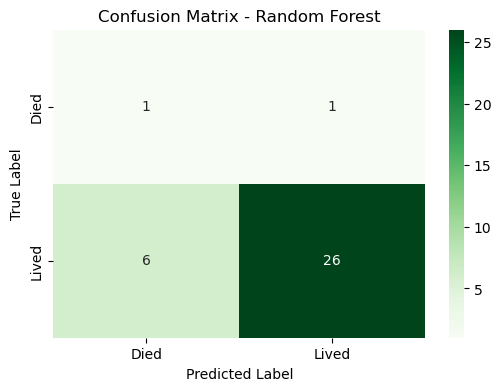

In [10]:
# Confusion Matrix Heatmap
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Died', 'Lived'], yticklabels=['Died', 'Lived'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

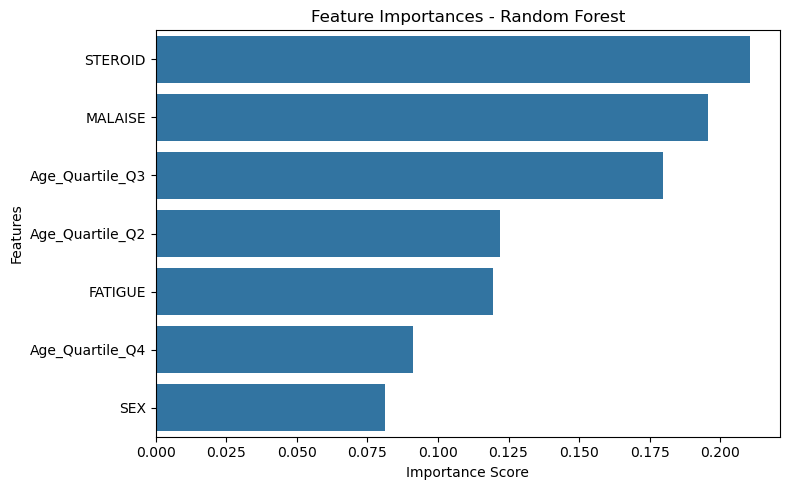

In [11]:
# Feature Importance Plot
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**What is the accuracy of your model?**

The Random Forest model achieved an **accuracy of 79.41%** on the test set, after splitting the dataset into 70% training and 30% testing data.

**Is this a good model? Why or why not?**

Yes, this is a good model. An accuracy close to 80% indicates strong predictive performance using a limited set of features. Random Forest is a robust ensemble learning method that reduces overfitting and handles non-linear relationships effectively. It also provides insights into which features are most important in predicting patient mortality. However, since the dataset is relatively small and the model was validated on a single split, the results should be interpreted cautiously. Applying cross-validation or testing on a larger dataset could provide a more reliable assessment.
